Dataset shape: (4424, 35)

Class Distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


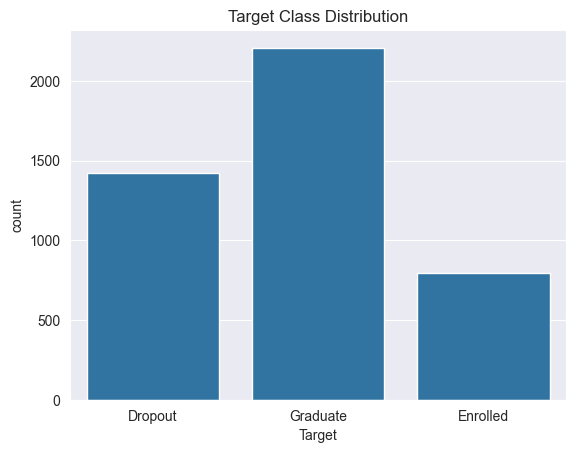

In [22]:
# Import EDA Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Kaggle dataset
df = pd.read_csv("dataset.csv")
print("Dataset shape:", df.shape)
df.head()

#print("\nMissing Values:")
#print(df.isnull().sum())

# Class balance
if 'Target' in df.columns:
    print("\nClass Distribution:")
    print(df['Target'].value_counts())
    sns.countplot(data=df, x='Target')
    plt.title("Target Class Distribution")
    plt.show()

num_cols = df.select_dtypes(include=[np.number]).columns




Vanilla Train/Test Split Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.88       284
           1       0.90      0.96      0.93       442

    accuracy                           0.91       726
   macro avg       0.92      0.90      0.90       726
weighted avg       0.91      0.91      0.91       726



C:\Users\swift\PycharmProjects\DropOutDA\.venv\lib\site-packages\xgboost\training.py:183: UserWarning: [15:33:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


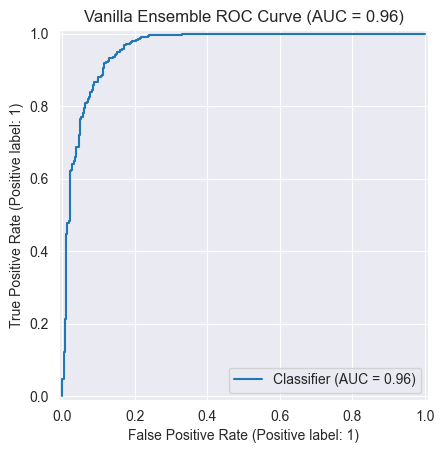

C:\Users\swift\PycharmProjects\DropOutDA\.venv\lib\site-packages\xgboost\training.py:183: UserWarning: [15:33:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


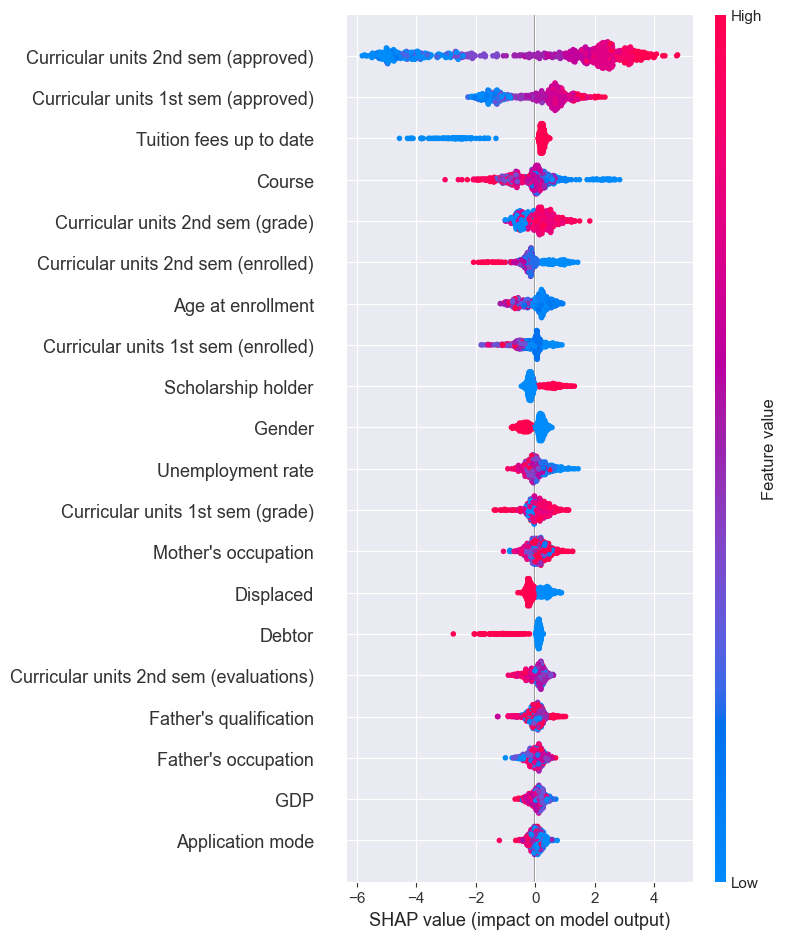

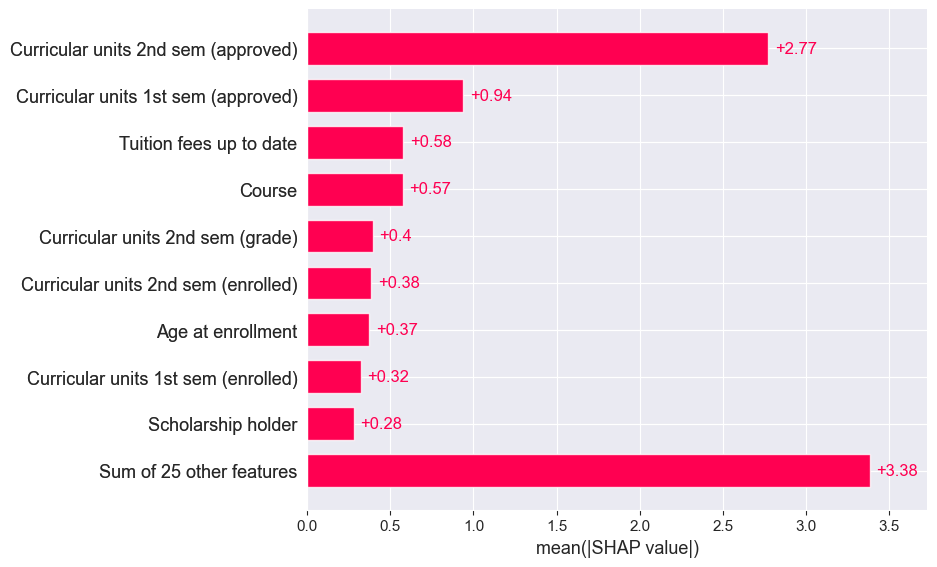

In [23]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay
from imblearn.over_sampling import SMOTE
import shap

# Load and clean dataset
df = pd.read_csv("dataset.csv")
df = df[df['Target'] != 'Enrolled']
df['Target'] = df['Target'].map({'Dropout': 0, 'Graduate': 1})

# Split features and target
X = df.drop(columns=['Target'])
y = df['Target']

# Select numeric columns and scale
num_cols = X.select_dtypes(include=[np.number]).columns
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[num_cols])

# Vanilla Split + Ensemble
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

logreg = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

vanilla_ensemble = VotingClassifier(estimators=[
    ('lr', logreg),
    ('rf', rf),
    ('xgb', xgb)
], voting='soft')

vanilla_ensemble.fit(X_train_res, y_train_res)
y_pred = vanilla_ensemble.predict(X_test)

print("\nVanilla Train/Test Split Report:")
print(classification_report(y_test, y_pred))

# ROC Curve (Vanilla)
y_proba = vanilla_ensemble.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_proba)
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title(f"Vanilla Ensemble ROC Curve (AUC = {roc_auc:.2f})")
plt.show()

# SHAP Explanation (XGBoost)

xgb.fit(X_train_res, y_train_res)
X_test_df = pd.DataFrame(X_test, columns=num_cols)
explainer = shap.Explainer(xgb)
shap_values = explainer(X_test_df)
shap.summary_plot(shap_values, features=X_test_df, feature_names=num_cols)

# SHAP Bar Plot (Mean Absolute Importance)
shap.plots.bar(shap_values)

C:\Users\swift\PycharmProjects\DropOutDA\.venv\lib\site-packages\xgboost\training.py:183: UserWarning: [15:33:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Fold 1 Report:
              precision    recall  f1-score   support

           0       0.94      0.85      0.89       285
           1       0.91      0.96      0.93       441

    accuracy                           0.92       726
   macro avg       0.92      0.90      0.91       726
weighted avg       0.92      0.92      0.92       726



C:\Users\swift\PycharmProjects\DropOutDA\.venv\lib\site-packages\xgboost\training.py:183: UserWarning: [15:33:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Fold 2 Report:
              precision    recall  f1-score   support

           0       0.90      0.85      0.88       284
           1       0.91      0.94      0.92       442

    accuracy                           0.90       726
   macro avg       0.90      0.90      0.90       726
weighted avg       0.90      0.90      0.90       726



C:\Users\swift\PycharmProjects\DropOutDA\.venv\lib\site-packages\xgboost\training.py:183: UserWarning: [15:33:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Fold 3 Report:
              precision    recall  f1-score   support

           0       0.93      0.86      0.89       284
           1       0.91      0.96      0.94       442

    accuracy                           0.92       726
   macro avg       0.92      0.91      0.91       726
weighted avg       0.92      0.92      0.92       726



C:\Users\swift\PycharmProjects\DropOutDA\.venv\lib\site-packages\xgboost\training.py:183: UserWarning: [15:33:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Fold 4 Report:
              precision    recall  f1-score   support

           0       0.91      0.85      0.88       284
           1       0.90      0.95      0.93       442

    accuracy                           0.91       726
   macro avg       0.91      0.90      0.90       726
weighted avg       0.91      0.91      0.91       726


Fold 5 Report:
              precision    recall  f1-score   support

           0       0.90      0.87      0.88       284
           1       0.92      0.94      0.93       442

    accuracy                           0.91       726
   macro avg       0.91      0.90      0.90       726
weighted avg       0.91      0.91      0.91       726



C:\Users\swift\PycharmProjects\DropOutDA\.venv\lib\site-packages\xgboost\training.py:183: UserWarning: [15:33:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


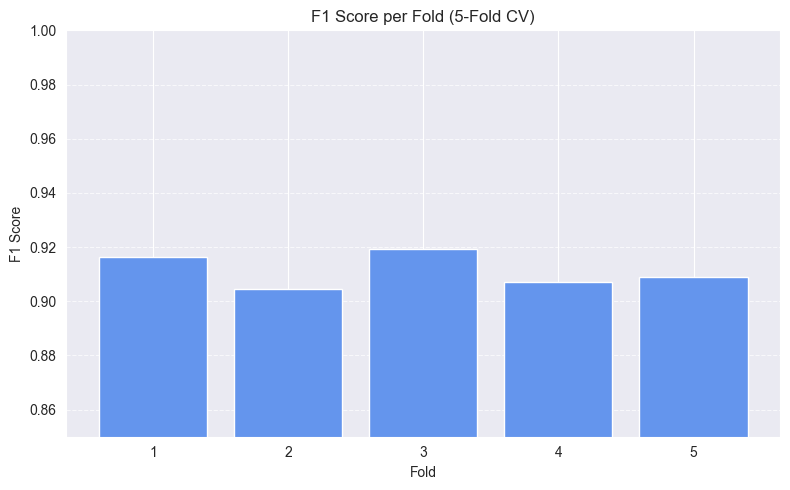


Mean F1 Score across folds: 0.9112311779841983


In [24]:
# K-Fold Cross-Validation + Ensemble
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
ensemble_scores = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_scaled, y)):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    logreg = LogisticRegression(max_iter=1000)
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

    ensemble = VotingClassifier(estimators=[
        ('lr', logreg),
        ('rf', rf),
        ('xgb', xgb)
    ], voting='soft')

    ensemble.fit(X_train_res, y_train_res)
    y_pred = ensemble.predict(X_test)

    print(f"\nFold {fold+1} Report:")
    print(classification_report(y_test, y_pred))

    f1 = classification_report(y_test, y_pred, output_dict=True)['weighted avg']['f1-score']
    ensemble_scores.append(f1)

# Bar Chart for Fold F1-Scores
plt.figure(figsize=(8, 5))
plt.bar(range(1, 6), ensemble_scores, color='cornflowerblue')
plt.ylim(0.85, 1.0)
plt.xlabel('Fold')
plt.ylabel('F1 Score')
plt.title('F1 Score per Fold (5-Fold CV)')
plt.xticks(range(1, 6))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nMean F1 Score across folds:", np.mean(ensemble_scores))
